In [1]:
!pip install qiskit
!pip install qiskit-ibm-runtime
!pip install qiskit_aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created w

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZGate

def diffusion_circuit(n):
    dc = QuantumCircuit(n)
    for i in range(n):
        dc.h(i)
        dc.x(i)
    mcz = ZGate().control(n-1)
    dc.append(mcz, range(n))
    for i in range(n):
        dc.x(i)
        dc.h(i)
    return dc

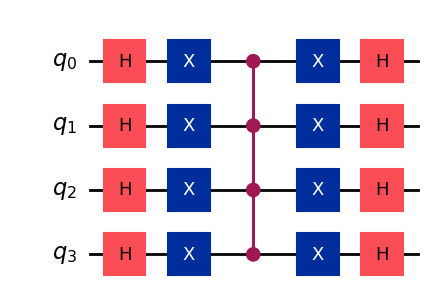

In [4]:
dc = diffusion_circuit(4)
dc.draw("mpl")

In [5]:
def build_oracle(strings_one):
    # If the function is never 1, the oracle is the identity.
    # Hence, we return an empty circuit.
    if len(strings_one) == 0:
        return QuantumCircuit()

    # Number of bits that the function takes as input:
    n = len(strings_one[0])

    qc = QuantumCircuit(n+1)
    for x in strings_one:
        # Find the positions in the string x where the bit is 0.
        # For this, we find the list of indices i such that x[i]=='0'.
        bits_zero = []
        for i in range(len(x)):
            val = x[i]
            if val == '0':
                bits_zero.append(i)

        # Step 1 in our construction.
        for bit in bits_zero:
            qc.x(bit)

        # Step 2.
        qc.mcx(list(range(n)), n)

        # Step 3.
        for bit in bits_zero:
            qc.x(bit)

    return qc

In [6]:
def grover_circuit(oracle, k, measure = False):
    # Number of qubits in the circuit (same as the oracle).
    # If we are working with an n-bit function, nqubits = n + 1.
    # We only measure the top qubits (hence nqubits-1 classical bits).
    nqubits = oracle.num_qubits
    qc = QuantumCircuit(nqubits,nqubits-1)

    # Set bottom qubit to |1>
    qc.x(nqubits-1) # Ancillary qubit for phase kickback
    # Apply Hadamard gates to all qubits.
    for i in range(nqubits):
        qc.h(i)

    # Apply k iterations of oracle + diffusion operator
    dc = diffusion_circuit(nqubits-1)
    qc.barrier()
    for i in range(k):
        qc.append(oracle, range(nqubits))
        qc.barrier()
        qc.append(dc, range(nqubits-1))
        qc.barrier()

    # Measure the top qubits if so instructed
    if measure:
        qc.measure(range(nqubits-1), range(nqubits-1))

    return qc

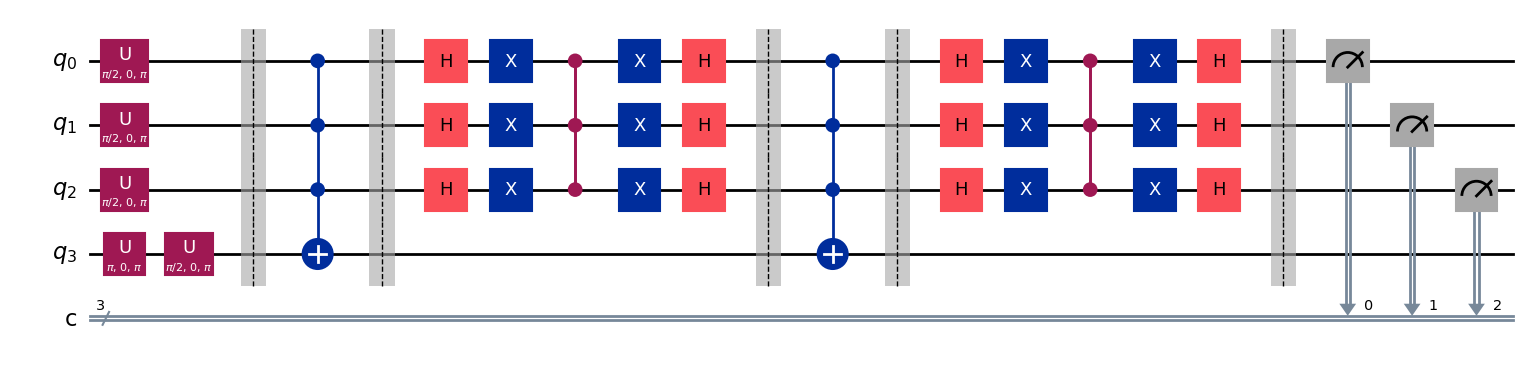

In [7]:
oracle = build_oracle(["111"])
grover = grover_circuit(oracle, 2, measure = True)
grover.decompose().draw("mpl")

In [8]:
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit_aer import AerSimulator

backend = AerSimulator()
sampler = Sampler(seed = 1234)
job = sampler.run([grover.decompose()], shots = 100)
results = job.result()
d = results[0].data.c
print(d.get_counts())

{'111': 95, '010': 1, '001': 1, '100': 1, '011': 1, '101': 1}


In [9]:
from qiskit.quantum_info import Statevector

grover = grover_circuit(oracle, 2)
sv = Statevector(grover)
print("The probability of 111 is", abs(sv['0111'])**2+abs(sv['1111'])**2)

The probability of 111 is 0.9453124999999969
